# Sea Surface Temperature (SST) Analysis - MUR L4 Data (June 2010 - November 2011)

This notebook demonstrates processing and visualization of MUR L4 Sea Surface Temperature data using the L3 pipeline. Based on principles from the combined CDOM-SST analysis but focused solely on SST visualization for the June 2010 - November 2011 period.

**Pipeline Steps:**

1. **Import libraries** and set up the environment.
2. **Define constants and parameters** for SST processing and geographical bounding box.
3. **SST Processing:**
   * Search for and load MUR L4 SST NetCDF files using L3 pipeline.
   * Inspect SST data structure.
   * Extract and process SST data.
   * Convert from Kelvin to Celsius and apply quality thresholds.
4. **SST Visualization:**
   * Plot raw SST data with oceanographic colormap.
   * Include coastlines, gridlines, and proper cartographic projection.

### Library Imports

Import essential libraries for file handling, numerical operations, plotting, and custom processing.

In [1]:
# Import essential libraries
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import cmocean  # For specialized oceanographic colormaps

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))  # adds cdom_sst to path

# Import L3 pipeline for MUR L4 data processing
from pipelines.l3_pipeline import L3DatasetLoader

# Suppress warnings
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

### Define Constants and Parameters

Define constants for SST processing, geographical area, and data paths.

In [2]:
# --- Geographical Parameters ---
# Texas-Louisiana Shelf region
lon_min, lon_max = -94.0, -88.0
lat_min, lat_max = 27.5, 30.5

# --- Date Range Configuration ---
# Specify the start and end dates for analysis
start_date = '2010-06-01'  # Format: YYYY-MM-DD
end_date = '2011-11-30'    # Format: YYYY-MM-DD

# --- MUR L4 SST Data Configuration ---
# Base directory pattern - use {year} as placeholder for year
data_dir_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
mur_l4_variable = 'analysed_sst'

# --- Quality Control Thresholds ---
min_sst_celsius_threshold = -2.0  # Minimum reasonable SST in Celsius
max_sst_celsius_threshold = 40.0  # Maximum reasonable SST in Celsius

print(f"Region: Lon ({lon_min}, {lon_max}), Lat ({lat_min}, {lat_max})")
print(f"Date Range: {start_date} to {end_date}")
print(f"SST Variable: {mur_l4_variable}")
print(f"Temperature Range Thresholds: {min_sst_celsius_threshold}°C to {max_sst_celsius_threshold}°C")

Region: Lon (-94.0, -88.0), Lat (27.5, 30.5)
Date Range: 2010-06-01 to 2011-11-30
SST Variable: analysed_sst
Temperature Range Thresholds: -2.0°C to 40.0°C


## MUR L4 SST Data Processing

### Search for MUR L4 SST Files

In [3]:
# Search for MUR L4 NetCDF files across multiple years based on date range
import pandas as pd

# Parse date range
start = pd.Timestamp(start_date)
end = pd.Timestamp(end_date)

# Determine which years to search
years = list(range(start.year, end.year + 1))
print(f"Searching for data in years: {years}")

# Collect all files from relevant year directories
mur_l4_files = []
for year in years:
    year_dir = data_dir_pattern.format(year=year)
    year_files = glob.glob(os.path.join(year_dir, '*.nc'))
    
    if year_files:
        print(f"  Year {year}: Found {len(year_files)} files in {year_dir}")
        mur_l4_files.extend(year_files)
    else:
        print(f"  Year {year}: No files found in {year_dir}")

# Sort files chronologically
mur_l4_files = sorted(mur_l4_files)

if not mur_l4_files:
    print(f"\nWarning: No MUR L4 files found across years {years}")
else:
    print(f"\nTotal files found: {len(mur_l4_files)}")
    
    # Filter files by actual date range
    print(f"\nFiltering files to date range {start_date} to {end_date}...")
    filtered_files = []
    
    for filepath in mur_l4_files:
        try:
            # Open file to check its time coordinate
            with xr.open_dataset(filepath) as ds:
                file_time = pd.to_datetime(ds.time.values[0])
                
                # Check if file is within date range
                if start <= file_time <= end:
                    filtered_files.append(filepath)
        except Exception as e:
            # If we can't read the file, skip it
            continue
    
    mur_l4_files = filtered_files
    print(f"Files within date range: {len(mur_l4_files)}")
    
    if mur_l4_files:
        print(f"First file: {os.path.basename(mur_l4_files[0])}")
        print(f"Last file: {os.path.basename(mur_l4_files[-1])}")
    
# Optionally limit files for testing
# mur_l4_files = mur_l4_files[:3]  # Use only first 3 files for quick testing
# print(f"Using {len(mur_l4_files)} MUR L4 files for processing.")

Searching for data in years: [2010, 2011]
  Year 2010: Found 184 files in E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_2010-06-01_2010-11-30
  Year 2011: Found 184 files in E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_2011-06-01_2011-11-30

Total files found: 368

Filtering files to date range 2010-06-01 to 2011-11-30...
Files within date range: 366
First file: 20100601090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
Last file: 20111129090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
Files within date range: 366
First file: 20100601090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
Last file: 20111129090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc


### Inspect MUR L4 Data Structure

In [4]:
# Inspect the structure of the first MUR L4 file
if mur_l4_files:
    print(f"Inspecting variables in the first MUR L4 file: {os.path.basename(mur_l4_files[0])}")
    try:
        with xr.open_dataset(mur_l4_files[0]) as ds:
            print(f"\nDataset dimensions:")
            for dim_name, dim_size in ds.dims.items():
                print(f"  {dim_name}: {dim_size}")
            
            print(f"\nMain data variables:")
            for var_name in ds.data_vars:
                var_obj = ds[var_name]
                print(f"  {var_name}: {var_obj.shape} - {var_obj.long_name if 'long_name' in var_obj.attrs else 'No description'}")
                if hasattr(var_obj, 'units'):
                    print(f"    Units: {var_obj.units}")
            
            print(f"\nCoordinate variables:")
            for coord_name in ds.coords:
                coord_obj = ds.coords[coord_name]
                if coord_name not in ds.dims:  # Don't repeat dimension coords
                    print(f"  {coord_name}: {coord_obj.shape}")
                    
    except Exception as e:
        print(f"Error inspecting MUR L4 file: {e}")
else:
    print("No MUR L4 files found to inspect.")

Inspecting variables in the first MUR L4 file: 20100601090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc

Dataset dimensions:
  time: 1
  lat: 17999
  lon: 36000

Main data variables:
  analysed_sst: (1, 17999, 36000) - analysed sea surface temperature
    Units: kelvin
  analysis_error: (1, 17999, 36000) - estimated error standard deviation of analysed_sst
    Units: kelvin
  mask: (1, 17999, 36000) - sea/land field composite mask
  sea_ice_fraction: (1, 17999, 36000) - sea ice area fraction
    Units: fraction (between 0 and 1)

Coordinate variables:


C:\Users\Makai\AppData\Local\Temp\ipykernel_28576\1749935770.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, dim_size in ds.dims.items():
<frozen _collections_abc>:894: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


### Load MUR L4 SST Data using L3 Pipeline

In [5]:
# Initialize L3 loader with MUR L4 variable and bounding box
l3_loader = L3DatasetLoader(
    variables=[mur_l4_variable], 
    bbox=(lon_min, lon_max, lat_min, lat_max)
)

# Load MUR L4 datasets
mur_l4_datasets = []
if mur_l4_files:
    try:
        mur_l4_datasets = l3_loader.load_multiple(mur_l4_files)
        print(f"Successfully loaded {len(mur_l4_datasets)} MUR L4 datasets.")
        
        if mur_l4_datasets:
            # Display information about the first dataset
            first_ds = mur_l4_datasets[0]
            print(f"\nFirst dataset shape: {first_ds[mur_l4_variable].shape}")
            print(f"Latitude range: {first_ds['lat'].values.min():.3f} to {first_ds['lat'].values.max():.3f}")
            print(f"Longitude range: {first_ds['lon'].values.min():.3f} to {first_ds['lon'].values.max():.3f}")
            sst_kelvin = first_ds[mur_l4_variable].values
            print(f"SST range (Kelvin): {np.nanmin(sst_kelvin):.2f} to {np.nanmax(sst_kelvin):.2f}")
            
    except Exception as e:
        print(f"Error loading MUR L4 datasets: {e}")
else:
    print("No MUR L4 files found to load.")

Successfully loaded 366 MUR L4 datasets.

First dataset shape: (1, 301, 601)
Latitude range: 27.500 to 30.500
Longitude range: -94.000 to -88.000
SST range (Kelvin): 300.26 to 303.24


### Process SST Data (Convert to Celsius and Apply Quality Control)

In [6]:
# Process the loaded MUR L4 SST data
processed_datasets = []

if mur_l4_datasets:
    # Get lat/lon from first dataset (MUR L4 has consistent grid)
    lat_data = mur_l4_datasets[0]['lat'].values
    lon_data = mur_l4_datasets[0]['lon'].values
    
    # Collect all SST data for averaging
    sst_list = []
    
    for i, ds in enumerate(mur_l4_datasets):
        # Extract SST data
        sst_kelvin = ds[mur_l4_variable].values
        
        # Convert SST from Kelvin to Celsius
        sst_celsius = sst_kelvin - 273.15
        
        # Apply quality control thresholds
        quality_mask = (
            (sst_celsius >= min_sst_celsius_threshold) & 
            (sst_celsius <= max_sst_celsius_threshold)
        )
        
        # Apply quality mask
        sst_qc = np.where(quality_mask, sst_celsius, np.nan)
        
        # Add to list for averaging
        sst_list.append(sst_qc)
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i+1}/{len(mur_l4_datasets)} datasets...")
        
    print(f"\nProcessed {len(mur_l4_datasets)} datasets successfully.")
    
    # Compute temporal mean across all datasets
    print(f"\nComputing temporal mean across all {len(sst_list)} datasets...")
    sst_stack = np.stack(sst_list, axis=0)
    sst_mean = np.nanmean(sst_stack, axis=0)
    
    # Store averaged data
    sst_data = {
        'sst_celsius': sst_mean,
        'lat': lat_data,
        'lon': lon_data,
        'n_datasets': len(sst_list)
    }
    
    print(f"✓ Temporal mean computed successfully")
    print(f"  Shape: {sst_data['sst_celsius'].shape}")
    print(f"  SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
    print(f"  Valid pixels: {np.sum(~np.isnan(sst_mean))}")
    
else:
    print("No MUR L4 datasets available for processing.")
    sst_data = None

Processed 100/366 datasets...
Processed 200/366 datasets...
Processed 200/366 datasets...
Processed 300/366 datasets...
Processed 300/366 datasets...

Processed 366 datasets successfully.

Computing temporal mean across all 366 datasets...

Processed 366 datasets successfully.

Computing temporal mean across all 366 datasets...
✓ Temporal mean computed successfully
  Shape: (1, 301, 601)
  SST range: 26.73 to 28.73 °C
  Valid pixels: 137002
✓ Temporal mean computed successfully
  Shape: (1, 301, 601)
  SST range: 26.73 to 28.73 °C
  Valid pixels: 137002


## SST Visualization

### Create SST Map with Cartographic Features

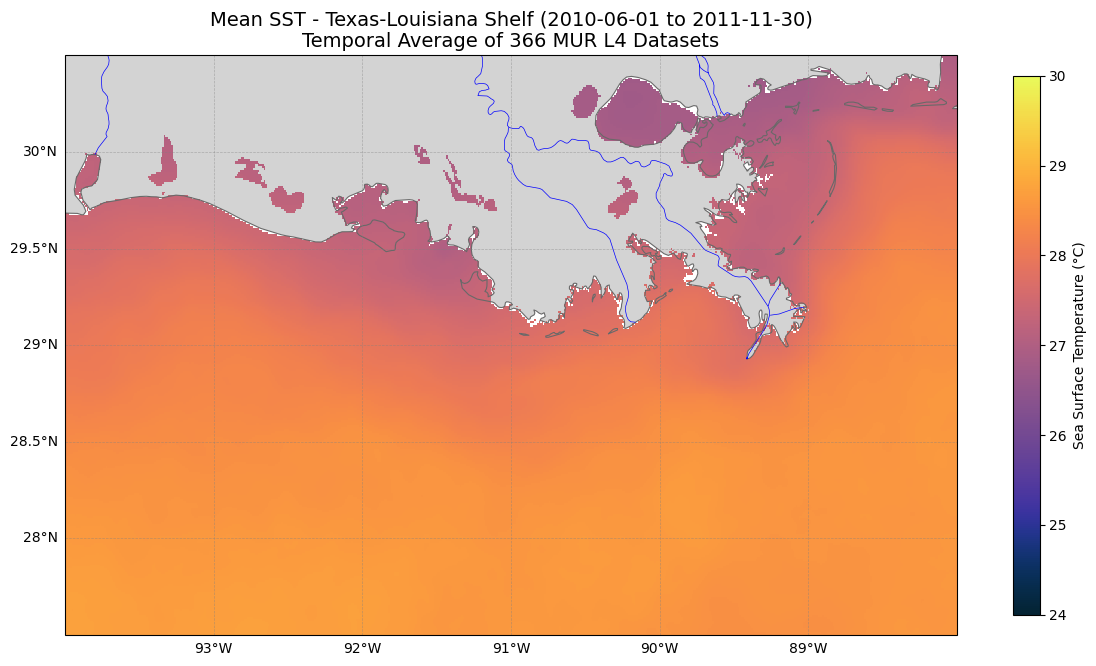


SST Statistics (Temporal Mean across 366 datasets):
  Valid data points: 137002
  Mean SST: 28.17 °C
  Min SST: 26.73 °C
  Max SST: 28.73 °C
  Standard deviation: 0.49 °C


In [9]:
if sst_data is not None:
    # Extract data
    sst_plot = sst_data['sst_celsius']
    lat_plot = sst_data['lat']
    lon_plot = sst_data['lon']
    n_datasets = sst_data['n_datasets']

    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Set extent
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.set_aspect(1.3, adjustable='box', anchor='C')
    
    # Define SST color range
    sst_vmin, sst_vmax = 24, 30
    
    # Plot SST
    sst_mesh = ax.pcolormesh(
        lon_plot, lat_plot, np.squeeze(sst_plot),
        cmap=cmocean.cm.thermal, shading='auto',
        vmin=sst_vmin, vmax=sst_vmax,
        transform=ccrs.PlateCarree()
    )
    
    # Add map features (consistent with CDOM styling)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimGray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='dimGray')
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
    
    # Add gridlines
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=True,
        linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    
    # Colorbar + title
    plt.colorbar(sst_mesh, label='Sea Surface Temperature (°C)', shrink=0.7)
    plt.title(f'Mean SST - Texas-Louisiana Shelf ({start_date} to {end_date})\n' + 
              f'Temporal Average of {n_datasets} MUR L4 Datasets', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    # Stats
    print(f"\nSST Statistics (Temporal Mean across {n_datasets} datasets):")
    print(f"  Valid data points: {np.sum(~np.isnan(sst_plot))}")
    print(f"  Mean SST: {np.nanmean(sst_plot):.2f} °C")
    print(f"  Min SST: {np.nanmin(sst_plot):.2f} °C")
    print(f"  Max SST: {np.nanmax(sst_plot):.2f} °C")
    print(f"  Standard deviation: {np.nanstd(sst_plot):.2f} °C")
else:
    print("No SST data available for visualization.")